In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
import pandas as pd
import scipy.io as sio

[('ecg_lead', (1129116, 1), 'double'), ('qrs_pattern1', (113, 1), 'double'), ('heartbeat_pattern1', (411, 1), 'double'), ('heartbeat_pattern2', (441, 1), 'double'), ('qrs_detections', (1903, 1), 'double')]


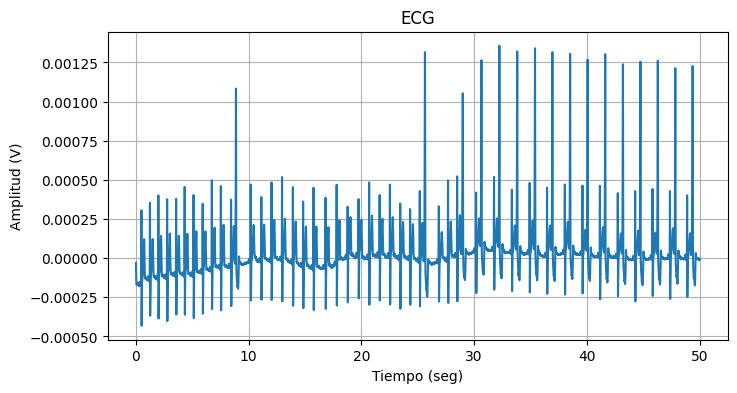

In [37]:
##################
# Lectura de ECG #
##################

fs = 1000 # Hz

##################
## ECG con ruido
##################


print(sio.whosmat('ecg.mat'))
mat_struct = sio.loadmat('./ecg.mat')

ecg_one_lead = mat_struct['ecg_lead']
N = len(ecg_one_lead)

tt = np.linspace(0, (1/fs)*(N-1), N)
# Normalizo la potencia
ecg_one_lead = ecg_one_lead.flatten() / np.var(ecg_one_lead)


plt.figure(figsize=(8, 4))
plt.plot(tt[0:50000], ecg_one_lead[0:50000])
plt.title('ECG')
plt.xlabel('Tiempo (seg)')
plt.ylabel('Amplitud (V)')
plt.grid()

In [43]:
att_min = 40 / 2 # Uso sosfiltfilt asi q reduzco a la mitad la atenuacion

fs1 = 0.1
fc1 = 1
fc2 = 35
fs2 = 50

ripple_db = 1 / 2 # Uso sosfiltfilt asi q reduzco a la mitad la atenuacion

fc = [fc1, fc2]
fst = [fs1, fs2]

sos_butt = sig.iirdesign(wp=fc, ws=fst, gpass=ripple_db, gstop=att_min, 
                    ftype='butter', analog=False, 
                    fs=fs, output='sos')

ECG_f_butt = sig.sosfiltfilt(sos_butt, ecg_one_lead)

sos_cauer = sig.iirdesign(wp=fc, ws=fst, gpass=ripple_db, gstop=att_min, 
                    ftype='ellip', analog=False, 
                    fs=fs, output='sos')

ECG_f_cauer = sig.sosfiltfilt(sos_cauer, ecg_one_lead)


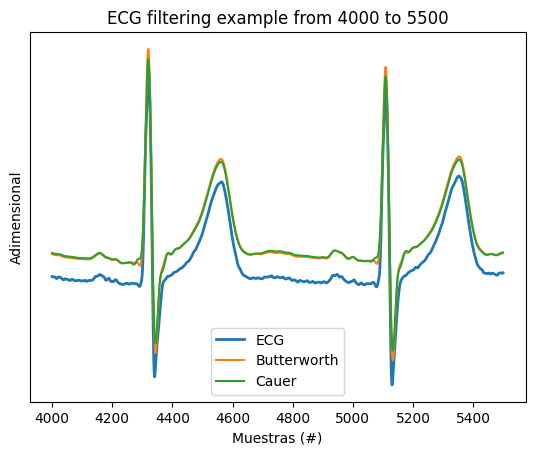

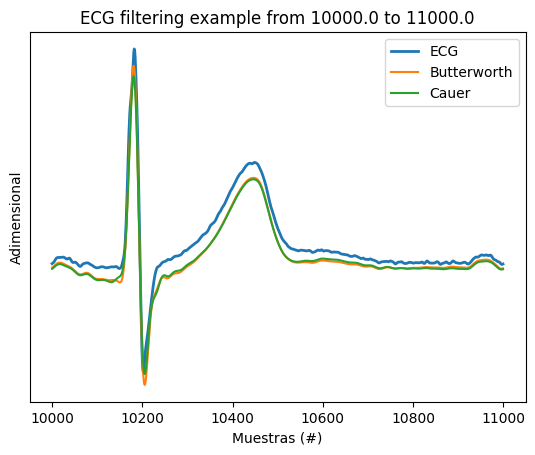

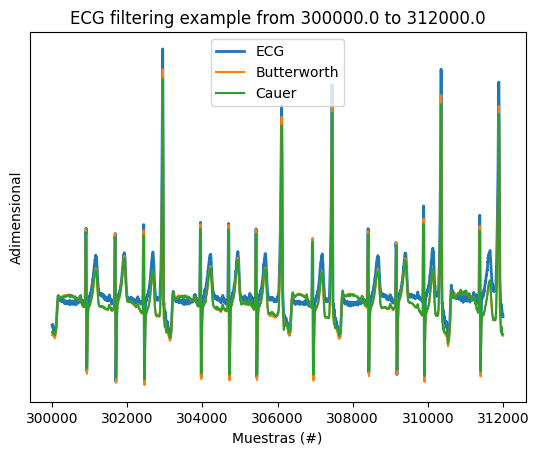

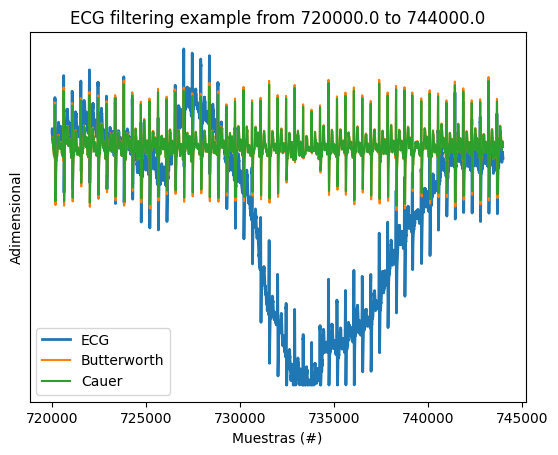

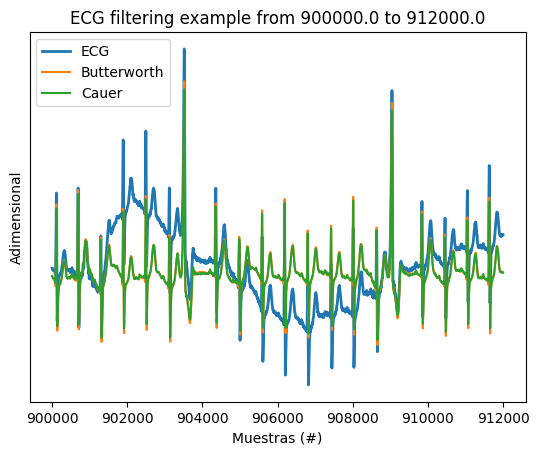

In [44]:
###################################
#%% Regiones de interés con ruido #
###################################
 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer')
    #plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

    ###################################
#%% Regiones de interés sin ruido #
###################################
 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer')
    #plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

La energia de baja frecuencia el filtro la elimino, asi que se comporta bien en ese sentido.

Por otro lado, destruyo la señal en la banda de paso. Se debe a la distorsion de la respuesta de fase ya que ya confirmamos que la respuesta en modulo cumple exactamente con la plantilla.


Usamos sosfiltfilt para arreglarlo.
X(t) -> X(w)
X(-t) -> X*(w)

EspejadoTemporal(x(n)) CONVOLUCION t(n) -> X*(w)*T(w)

Vuelvo a pasar por el mismo sistema:

EspejadoTemporal(x(-n) CONVOLUCION t(n)) CONVOLUCION t(n) -> X(w) * T*(w) * T(w) = X(w)*|T|**2

Con esto logro un filtro de fase 0 perfecta. Anulo por completo el efecto de la fase.
